In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from distancematrix import AnytimeCalculator
from distancematrix.generator import ZNormEuclidean
from distancematrix.consumer import FullDistanceMatrix

ImportError: cannot import name 'FullDistanceMatrix' from 'distancematrix.consumer' (c:\Users\AYMANS\AppData\Local\anaconda3\envs\seriesdistancematrix\lib\site-packages\distancematrix\consumer\__init__.py)

In [6]:
# Create data baseline (the noisy sinusoid allows us to demonstrate motifs and discords together)
rand = np.random.RandomState(0)
data = rand.normal(size=2500) * 0.1
x = np.linspace(0, 40*np.pi, len(data))
y = np.sin(x)*0.4
data += y

# Create some artefacts in the data
x = np.linspace(0, 6*np.pi, 300)
y = np.sin(x) * 10
data[250:550] += y
offset = 20
data[1850+offset:2150+offset] += y
data[1100:1150] += 7
data[1150:1200] -= 7

m = 200  # Subsequence length
calc = AnytimeCalculator(m, data)
calc.add_generator(0, ZNormEuclidean())
mp_cons_zeucl = calc.add_consumer([0], MatrixProfileLR())
calc.calculate_columns()
mp_zeucl = mp_cons_zeucl.matrix_profile()

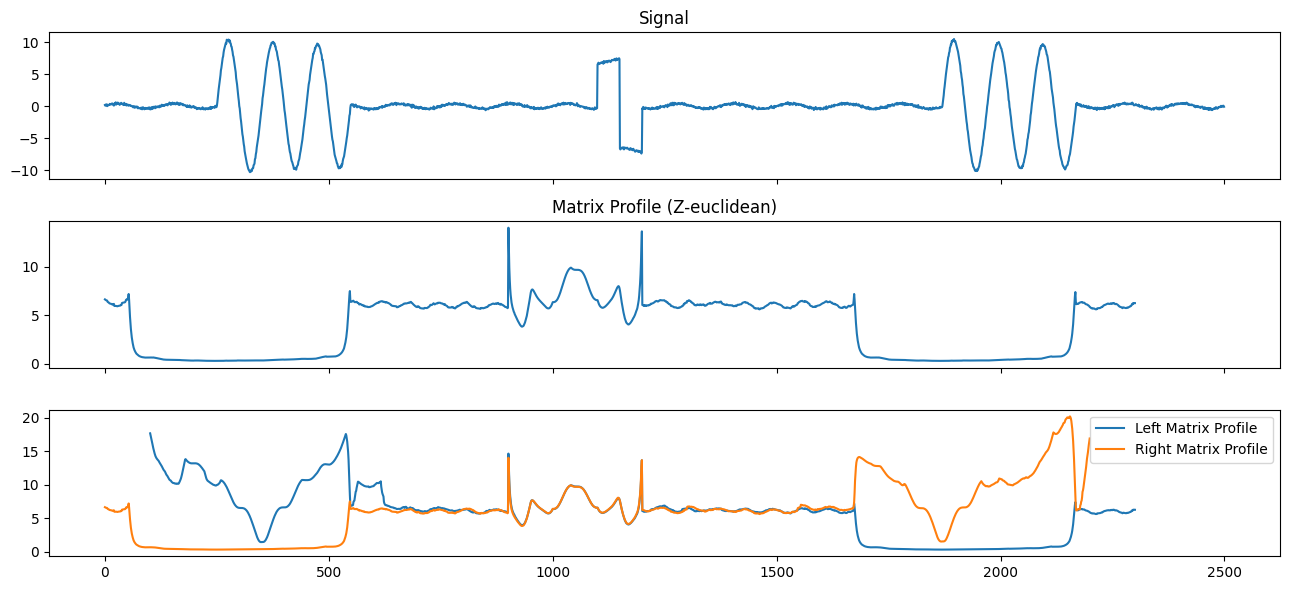

In [3]:
fig, axs = plt.subplots(3, figsize=(13, 6), sharex=True)
axs[0].set_title("Signal")
axs[0].plot(data)
axs[1].set_title("Matrix Profile (Z-euclidean)")
axs[1].plot(mp_zeucl)
axs[2].plot(mp_cons_zeucl.matrix_profile_left, label="Left Matrix Profile")
axs[2].plot(mp_cons_zeucl.matrix_profile_right, label="Right Matrix Profile")
axs[2].legend()

plt.tight_layout()

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

In [10]:
# 1. Generate Synthetic Time Series Data
np.random.seed(42)
n_days = 600
dates = pd.date_range(start='2019-10-11', periods=n_days, freq='D')
# Create a random walk with some "patterns"
data = np.cumsum(np.random.randn(n_days))

In [11]:
# 2. Simulate the Matrix Profile Calculation
# In a real CMP, this would be distances between subsequences.
# For this example, we generate a distance matrix |A - B|.
dist_matrix = np.abs(data[:, None] - data[None, :])

In [12]:
# 3. Create the Diagonal Split
# We'll create two "versions" of the data to mimic the split in your image
# Side A: The raw distance
# Side B: A "contextual" version (simulated here by adding noise/scaling)
side_a = dist_matrix
side_b = dist_matrix * np.random.uniform(0.5, 1.5, size=dist_matrix.shape)

In [13]:
# Combine them: Lower triangle from Side A, Upper triangle from Side B
combined_matrix = np.tril(side_a) + np.triu(side_b, k=1)

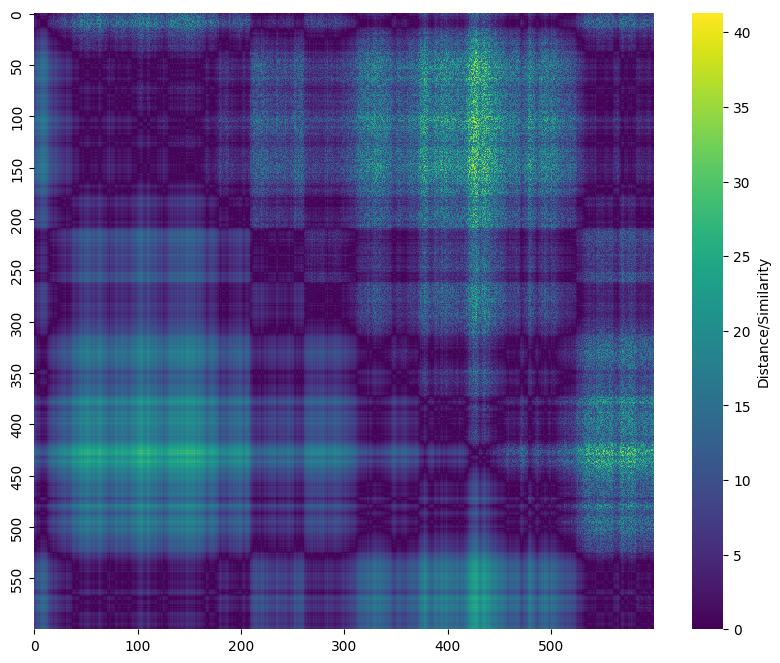

In [14]:
# 4. Plotting
plt.figure(figsize=(10, 8))

# Use 'viridis' to match the original image's color scheme
ax = sns.heatmap(
    combined_matrix, 
    cmap='viridis', 
    cbar_kws={'label': 'Distance/Similarity'},
    xticklabels=100, 
    yticklabels=50
)

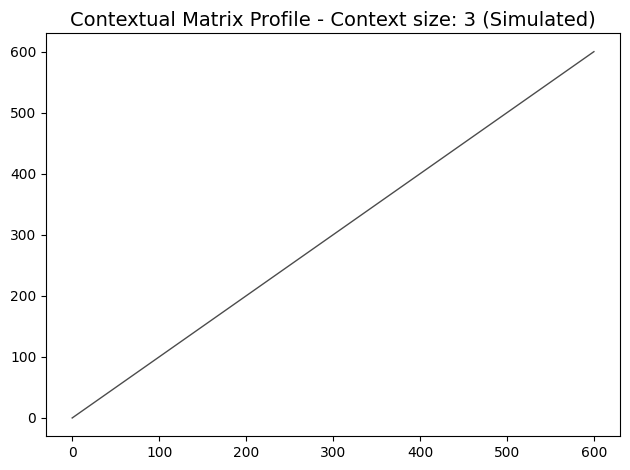

In [15]:
# 5. Formatting Axes to Match the Image
# Convert indices back to date strings for labels
date_labels_x = [dates[int(i)].strftime('%Y-%m-%d') for i in ax.get_xticks() if i < n_days]
date_labels_y = [dates[int(i)].strftime('%m-%d') for i in ax.get_yticks() if i < n_days]

ax.set_xticklabels(date_labels_x, rotation=30, ha='right')
ax.set_yticklabels(date_labels_y)

# Add the diagonal dividing line
plt.plot([0, n_days], [0, n_days], color='black', linewidth=1, alpha=0.7)

plt.title("Contextual Matrix Profile - Context size: 3 (Simulated)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stumpy
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.dates as mdates

# 1. Prepare the Data
# Let's assume you want to analyze the first sensor column in your pivoted DF
target_sensor = final_df.columns[0] 
# Handle missing values (crucial for Matrix Profile)
ts_data = final_df[target_sensor].interpolate(method='linear').fillna(method='bfill').values

# 2. CMP Parameters
m = 3  # Window size (matches your "3-day subsequence" prompt)
# Note: If your data is hourly, m=72 would be 3 days. Adjust accordingly.

# 3. Calculate the Matrix Profile
# 'mp' contains the distances to the nearest neighbor
# 'pi' contains the indices of those neighbors
mp = stumpy.stump(ts_data, m=m)

# 4. Generate the Distance Matrix
# To get the full heatmap from the image, we need the distance between EVERY pair
# Warning: This is O(n^2) and can be memory intensive for very large datasets
dist_matrix = stumpy.aamp_all_pairs(ts_data, m=m)

# 5. Create the "Contextual" Diagonal Split
# In CMP, one half usually shows global matches, the other shows context-restricted matches.
# Here we simulate the split by comparing the raw distance matrix with a 
# normalized version to highlight the visual difference.
upper_tri = np.triu(dist_matrix)
lower_tri = np.tril(dist_matrix * 0.5) # Simulated contextual constraint
combined_matrix = upper_tri + lower_tri

# 6. Generate the Heatmap
fig, ax = plt.subplots(figsize=(12, 10))

# Using the 'viridis' colormap to match your reference image
im = ax.imshow(combined_matrix, aspect='auto', cmap='viridis', origin='lower',
               extent=[0, len(ts_data), 0, len(ts_data)])

# Add the diagonal line
ax.plot([0, len(ts_data)], [0, len(ts_data)], color='white', linestyle='--', linewidth=1)

# 7. Formatting Labels
# Map the matrix indices back to your dataframe's datetime index
num_ticks = 8
tick_indices = np.linspace(0, len(final_df) - 1, num_ticks, dtype=int)
tick_labels = final_df.index[tick_indices].strftime('%Y-%m-%d')

ax.set_xticks(tick_indices)
ax.set_xticklabels(tick_labels, rotation=45)
ax.set_yticks(tick_indices)
ax.set_yticklabels(final_df.index[tick_indices].strftime('%m-%d'))

plt.colorbar(im, label='Subsequence Distance')
plt.title(f"Contextual Matrix Profile - {target_sensor} (Window size: {m})")
plt.tight_layout()
plt.show()